In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('karnataka_irrigation_dataset.csv')

In [4]:
print(df.head())
print(df.size)

    latitude  longitude  soil_moisture_percent  soil_temperature_c  \
0  14.121781  75.681384              37.942952           25.369189   
1  18.155000  75.498104              58.789877           26.678449   
2  16.623958  74.792693              69.594207           24.436665   
3  15.690609  76.732700              31.596265           30.301132   
4  12.592130  76.144809              75.684616           26.242251   

   soil_moisture_change_percent  rainfall_mm_today  \
0                      2.848900           4.553766   
1                      0.770524           7.858504   
2                      2.740878           8.386448   
3                      0.326125           3.868117   
4                     -3.377592          12.025398   

   rainfall_forecast_next_3days_mm  
0                        22.349829  
1                        14.810334  
2                        22.071346  
3                        17.713467  
4                        12.481870  
70000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   latitude                         10000 non-null  float64
 1   longitude                        10000 non-null  float64
 2   soil_moisture_percent            10000 non-null  float64
 3   soil_temperature_c               10000 non-null  float64
 4   soil_moisture_change_percent     10000 non-null  float64
 5   rainfall_mm_today                10000 non-null  float64
 6   rainfall_forecast_next_3days_mm  10000 non-null  float64
dtypes: float64(7)
memory usage: 547.0 KB
None
           latitude     longitude  soil_moisture_percent  soil_temperature_c  \
count  10000.000000  10000.000000           10000.000000        10000.000000   
mean      14.959117     76.270384              50.052737           27.947621   
std        2.013411      1.301825              1

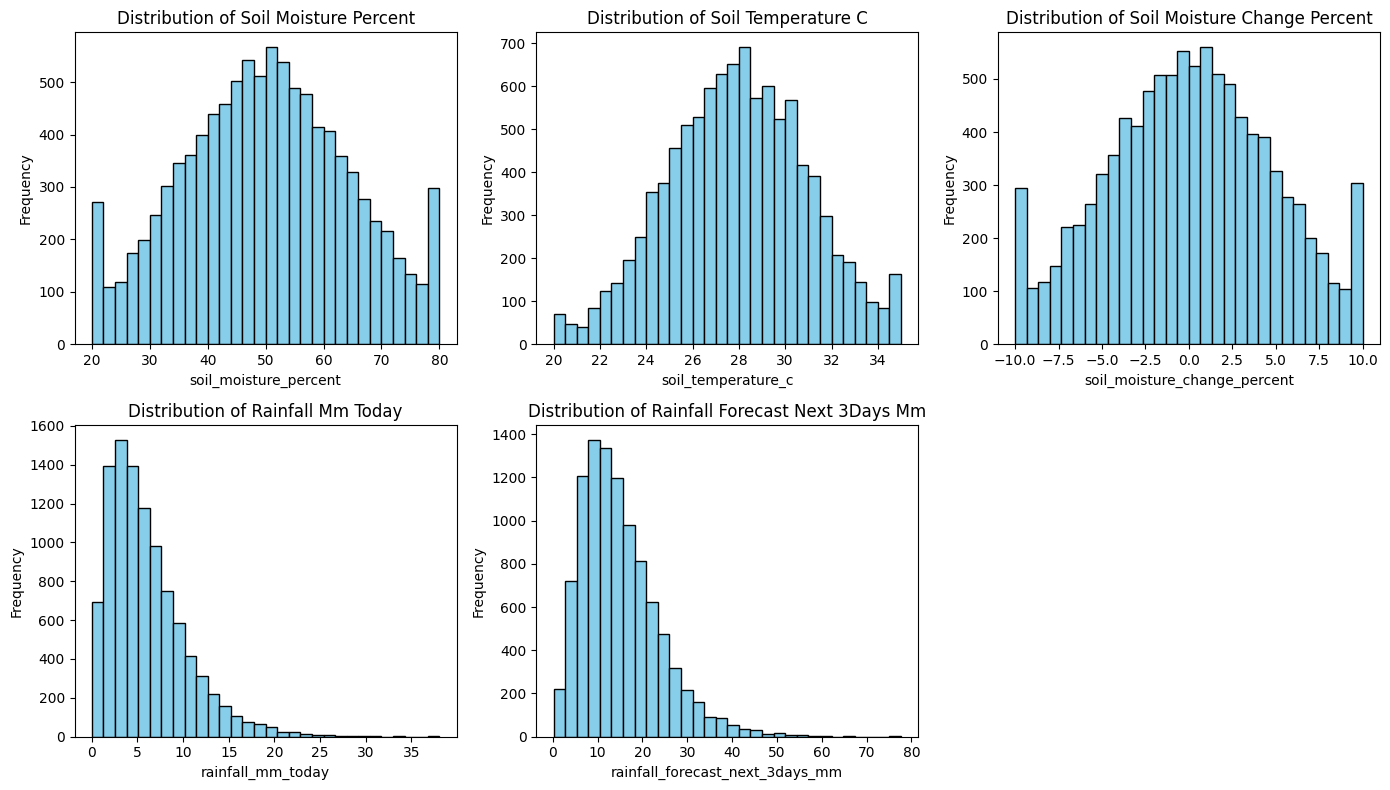

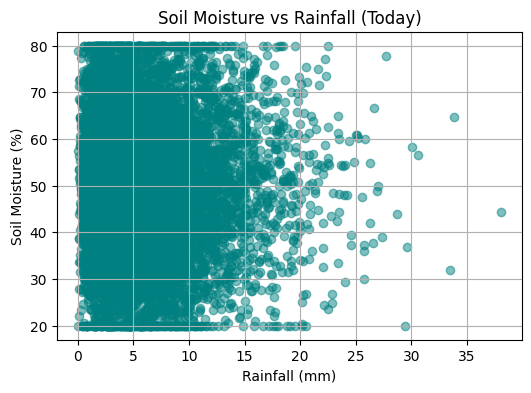

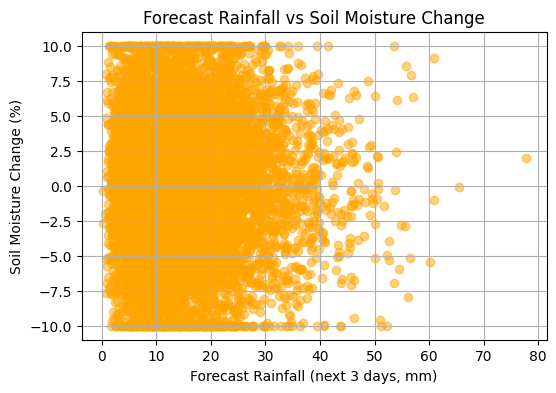

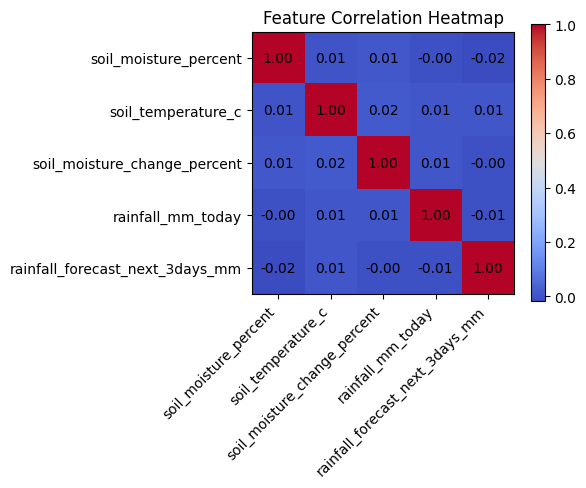

In [5]:
import matplotlib.pyplot as plt
import pandas as pd



# Set plot style
plt.style.use("seaborn-v0_8-muted")

# 1️⃣ --- Basic overview ---
print(df.info())
print(df.describe())

# 2️⃣ --- Distribution plots for each feature ---
columns = [
    "soil_moisture_percent",
    "soil_temperature_c",
    "soil_moisture_change_percent",
    "rainfall_mm_today",
    "rainfall_forecast_next_3days_mm"
]

plt.figure(figsize=(14, 8))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3️⃣ --- Relationship between Soil Moisture and Rainfall ---
plt.figure(figsize=(6, 4))
plt.scatter(df["rainfall_mm_today"], df["soil_moisture_percent"], alpha=0.5, c="teal")
plt.title("Soil Moisture vs Rainfall (Today)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Soil Moisture (%)")
plt.grid(True)
plt.show()

# 4️⃣ --- Relationship between Forecast Rainfall and Moisture Change ---
plt.figure(figsize=(6, 4))
plt.scatter(df["rainfall_forecast_next_3days_mm"], df["soil_moisture_change_percent"], alpha=0.5, c="orange")
plt.title("Forecast Rainfall vs Soil Moisture Change")
plt.xlabel("Forecast Rainfall (next 3 days, mm)")
plt.ylabel("Soil Moisture Change (%)")
plt.grid(True)
plt.show()

# 5️⃣ --- Correlation heatmap ---
import numpy as np

corr = df[columns].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Feature Correlation Heatmap")
plt.colorbar(im)
plt.tight_layout()
plt.show()


In [6]:
import numpy as np

# --- Realistic Irrigation Volume Generation ---
# Base ET₀-like term (depends on soil temperature)
base_irrigation = 0.25 * (df["soil_temperature_c"] - 20)  # base demand rises with temperature

# Reduce irrigation when soil moisture is high
moisture_effect = 0.15 * (60 - df["soil_moisture_percent"])  # higher moisture → smaller (negative)

# Rainfall reductions
rain_today_effect = -0.1 * df["rainfall_mm_today"]
rain_forecast_effect = -0.05 * df["rainfall_forecast_next_3days_mm"]

# Soil moisture trend: rising moisture = less irrigation
moisture_change_effect = -0.2 * df["soil_moisture_change_percent"]

# Combine all effects + small random noise
df["irrigation_volume_mm_today"] = (
    base_irrigation + moisture_effect + rain_today_effect +
    rain_forecast_effect + moisture_change_effect +
    np.random.normal(0, 0.3, len(df))
)

# Clip to realistic 0–25 mm/day range (field irrigation range)
df["irrigation_volume_mm_today"] = np.clip(df["irrigation_volume_mm_today"], 0, 25)

# Preview
df[[
    "soil_moisture_percent", "soil_temperature_c", "soil_moisture_change_percent",
    "rainfall_mm_today", "rainfall_forecast_next_3days_mm", "irrigation_volume_mm_today"
]].head(10)


,soil_moisture_percent,soil_temperature_c,soil_moisture_change_percent,rainfall_mm_today,rainfall_forecast_next_3days_mm,irrigation_volume_mm_today
0,37.942952,25.369189,2.848900,4.553766,22.349829,2.178091
1,58.789877,26.678449,0.770524,7.858504,14.810334,0.000000
2,69.594207,24.436665,2.740878,8.386448,22.071346,0.000000
3,31.596265,30.301132,0.326125,3.868117,17.713467,5.368156
4,75.684616,26.242251,-3.377592,12.025398,12.481870,0.000000
5,48.071734,20.000000,-5.579676,3.734561,21.748538,1.039410
6,35.374679,35.000000,-1.315014,4.258528,23.301597,6.054310
7,61.366322,26.288197,-3.831381,3.395223,5.885259,1.542084
8,43.303183,26.270227,-0.598596,7.130365,13.962830,2.954491
9,48.773950,33.014835,-2.459385,5.268363,19.379824,3.645725


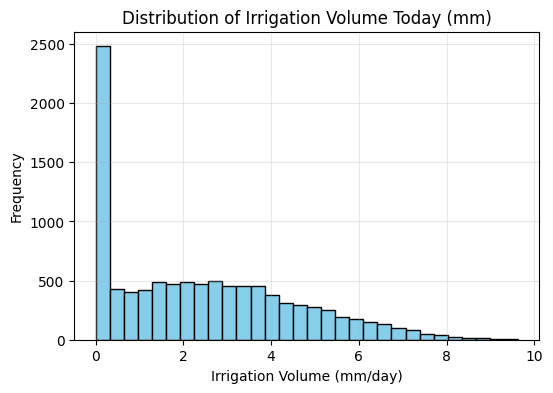

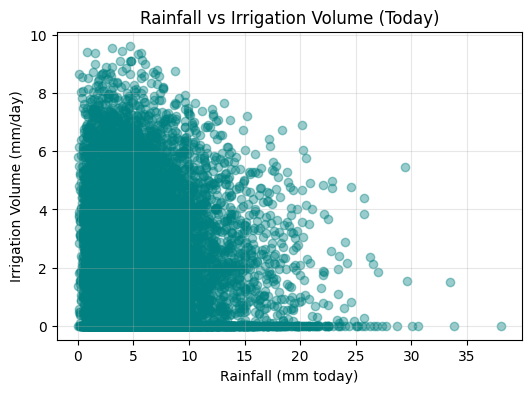

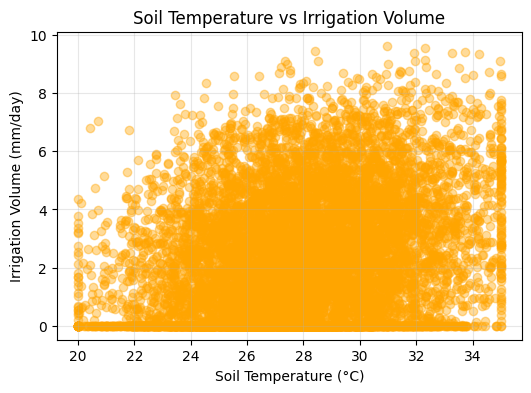

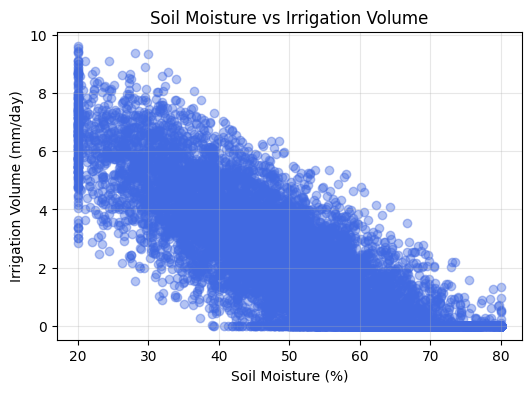

In [7]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-muted")

# 1️⃣ --- Distribution of irrigation volume ---
plt.figure(figsize=(6, 4))
plt.hist(df["irrigation_volume_mm_today"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Irrigation Volume Today (mm)")
plt.xlabel("Irrigation Volume (mm/day)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# 2️⃣ --- Irrigation vs Rainfall ---
plt.figure(figsize=(6, 4))
plt.scatter(df["rainfall_mm_today"], df["irrigation_volume_mm_today"], alpha=0.4, c="teal")
plt.title("Rainfall vs Irrigation Volume (Today)")
plt.xlabel("Rainfall (mm today)")
plt.ylabel("Irrigation Volume (mm/day)")
plt.grid(True, alpha=0.3)
plt.show()

# 3️⃣ --- Irrigation vs Soil Temperature ---
plt.figure(figsize=(6, 4))
plt.scatter(df["soil_temperature_c"], df["irrigation_volume_mm_today"], alpha=0.4, c="orange")
plt.title("Soil Temperature vs Irrigation Volume")
plt.xlabel("Soil Temperature (°C)")
plt.ylabel("Irrigation Volume (mm/day)")
plt.grid(True, alpha=0.3)
plt.show()

# 4️⃣ --- Irrigation vs Soil Moisture ---
plt.figure(figsize=(6, 4))
plt.scatter(df["soil_moisture_percent"], df["irrigation_volume_mm_today"], alpha=0.4, c="royalblue")
plt.title("Soil Moisture vs Irrigation Volume")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Irrigation Volume (mm/day)")
plt.grid(True, alpha=0.3)
plt.show()


In [26]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

# --- 1️⃣ Augment dataset for heavy rainfall cases ---
n_extreme = int(0.10 * len(df))
extreme = df.sample(n_extreme, replace=True).copy()

# Simulate heavy rainfall scenarios
extreme["rainfall_mm_today"] = np.random.uniform(50, 300, n_extreme)
extreme["rainfall_forecast_next_3days_mm"] = np.random.uniform(100, 600, n_extreme)
extreme["soil_moisture_percent"] = np.random.uniform(60, 100, n_extreme)

# Combine with original dataset
df_aug = pd.concat([df, extreme], ignore_index=True)

# --- 2️⃣ Define rainfall impact function ---
def rainfall_penalty(today_mm, forecast_mm):
    """
    Smoothly reduce irrigation when rainfall increases.
    - >5 mm today  => strong reduction
    - >50 mm next 3 days => strong reduction
    """
    # Sigmoid decay to smoothly taper irrigation demand
    today_factor = 1 / (1 + np.exp((today_mm - 5) / 1.5))      # drops after ~5 mm/day
    forecast_factor = 1 / (1 + np.exp((forecast_mm - 50) / 10))  # drops after ~50 mm/3days
    return today_factor * forecast_factor

# --- 3️⃣ Recalculate realistic irrigation target ---
penalty = rainfall_penalty(
    df_aug["rainfall_mm_today"].values,
    df_aug["rainfall_forecast_next_3days_mm"].values
)

df_aug["irrigation_volume_mm_today"] = (
    penalty * (
        0.25 * (df_aug["soil_temperature_c"] - 20)
        + 0.15 * (60 - df_aug["soil_moisture_percent"])
        - 0.1 * df_aug["soil_moisture_change_percent"]
        + np.random.normal(0, 0.3, len(df_aug))
    )
)

# Clip to realistic range
df_aug["irrigation_volume_mm_today"] = np.clip(df_aug["irrigation_volume_mm_today"], 0, 25)

# --- 4️⃣ Train-test split ---
X = df_aug[[
    "latitude",
    "longitude",
    "soil_moisture_percent",
    "soil_temperature_c",
    "soil_moisture_change_percent",
    "rainfall_mm_today",
    "rainfall_forecast_next_3days_mm"
]]
y = df_aug["irrigation_volume_mm_today"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5️⃣ Train XGBoost model ---
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# --- 6️⃣ Evaluate model ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("✅ Model Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.3f} mm/day")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} mm/day")
print(f"R² Score: {r2:.3f}")

# --- 7️⃣ Save model ---
pickle.dump(model, open("xgb_irrigation_model.pkl", "wb"))
print("\n💾 Retrained model saved successfully as 'xgb_irrigation_model.pkl'")


✅ Model Evaluation Results:
Mean Absolute Error (MAE): 0.122 mm/day
Root Mean Squared Error (RMSE): 0.185 mm/day
R² Score: 0.987

💾 Retrained model saved successfully as 'xgb_irrigation_model.pkl'


In [27]:
import pickle
pickle.dump(model, open("xgb_irrigation_model.pkl", "wb"))


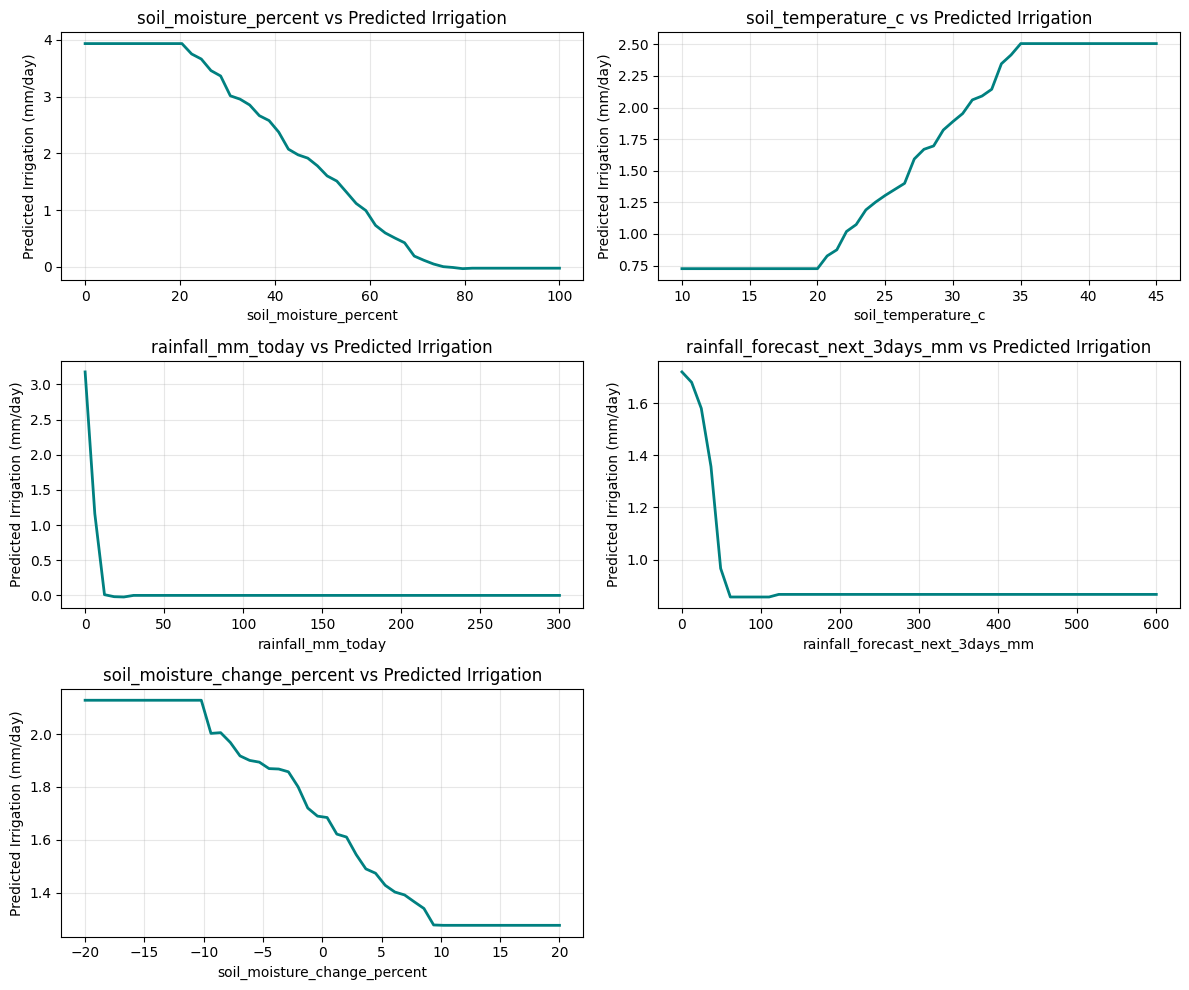

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed baseline input (typical farm day)
base = {
    "latitude": 15.0,
    "longitude": 75.0,
    "soil_moisture_percent": 50,
    "soil_temperature_c": 28,
    "soil_moisture_change_percent": 0,
    "rainfall_mm_today": 5,
    "rainfall_forecast_next_3days_mm": 10
}

# Helper to predict easily
def predict_from_dict(d):
    arr = np.array([[d[f] for f in [
        "latitude", "longitude", "soil_moisture_percent",
        "soil_temperature_c", "soil_moisture_change_percent",
        "rainfall_mm_today", "rainfall_forecast_next_3days_mm"
    ]]], dtype=np.float32)
    return float(model.predict(arr)[0])

# Sweep each feature
sweeps = {}

# 1️⃣ Soil Moisture (%)
vals = np.linspace(0, 100, 50)
sweeps["soil_moisture_percent"] = [predict_from_dict({**base, "soil_moisture_percent": v}) for v in vals]

# 2️⃣ Soil Temperature (°C)
vals_temp = np.linspace(10, 45, 50)
sweeps["soil_temperature_c"] = [predict_from_dict({**base, "soil_temperature_c": v}) for v in vals_temp]

# 3️⃣ Rainfall Today (mm)
vals_rain = np.linspace(0, 300, 50)
sweeps["rainfall_mm_today"] = [predict_from_dict({**base, "rainfall_mm_today": v}) for v in vals_rain]

# 4️⃣ Forecast Rainfall (mm)
vals_forecast = np.linspace(0, 600, 50)
sweeps["rainfall_forecast_next_3days_mm"] = [predict_from_dict({**base, "rainfall_forecast_next_3days_mm": v}) for v in vals_forecast]

# 5️⃣ Soil Moisture Change (%)
vals_change = np.linspace(-20, 20, 50)
sweeps["soil_moisture_change_percent"] = [predict_from_dict({**base, "soil_moisture_change_percent": v}) for v in vals_change]

# 📈 Plot results
plt.figure(figsize=(12, 10))
for i, (key, values) in enumerate(sweeps.items(), 1):
    plt.subplot(3, 2, i)
    xvals = {
        "soil_moisture_percent": np.linspace(0, 100, 50),
        "soil_temperature_c": np.linspace(10, 45, 50),
        "rainfall_mm_today": np.linspace(0, 300, 50),
        "rainfall_forecast_next_3days_mm": np.linspace(0, 600, 50),
        "soil_moisture_change_percent": np.linspace(-20, 20, 50)
    }[key]
    plt.plot(xvals, values, color="teal", lw=2)
    plt.title(f"{key} vs Predicted Irrigation")
    plt.xlabel(key)
    plt.ylabel("Predicted Irrigation (mm/day)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
